# Real-data robustness study: one figure per property

Reads `results/real_robustness/` produced by

```bash
python run_real_data.py --study robustness --sweep all --seeds 0:50 --workers 12
python run_real_data.py --study robustness --ja          # JA-Ranking reanalysis (figure A, panel a)
python run_real_data.py --study robustness --clean-fit   # judge-level position effects (figure A, panel d)
```

Design: `code/plan/2026-09-06-real-data-robustness-plan.md`, Section 22. Metric: excess held-out human log loss over the test-pool BTL floor; bands are $\pm1.96$ Monte Carlo s.e. over seeds.
Methods: Human-only; Pooled-LLM + scale (no judge structure, no order term); Consensus-cal (rank-0 staged, $s=\alpha\widehat\mu$); DIAL-$\mu$ (rank 0, joint weighted likelihood, GACV weight); DIAL (rank and weight by GACV); DIAL-noDeb (DIAL without the order term).

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

REPO = Path.cwd().parent; sys.path.insert(0, str(REPO))
from experiments.real_data.robustness_plot import load, aggregate, aggregate_spectest
RESULTS = REPO / "results" / "real_robustness"; FIGURES = REPO / "figures"; FIGURES.mkdir(exist_ok=True)
DATASETS = ["arena_33k", "mt_bench", "pandalm"]; DLAB = {"arena_33k": "Chatbot Arena", "mt_bench": "MT-Bench", "pandalm": "PandaLM"}
# Shared method panel (experiments/style.py): five presented methods plus appendix diagnostics.
from experiments.style import PRESENTED, APPENDIX, LABEL as _LABEL, STYLE as _STYLE, INK, INK_SOFT, GRID
METHODS = list(PRESENTED)
LABEL = dict(_LABEL); LABEL["oracle_test"] = "test-oracle weight"
STYLE = dict(_STYLE); STYLE["oracle_test"] = dict(STYLE["oracle"])
mpl.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"], "font.size": 8, "axes.labelsize": 8.5,
                     "axes.titlesize": 9, "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5, "axes.edgecolor": INK_SOFT,
                     "axes.linewidth": 0.6, "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 300, "figure.dpi": 130})

rows = {d: load(d, REPO) for d in DATASETS if (RESULTS / d / "rows.jsonl").exists()}
agg = {d: aggregate(df) for d, df in rows.items()}
spec = aggregate_spectest(rows["arena_33k"]) if "arena_33k" in rows else pd.DataFrame()
for d, df in rows.items():
    ok = df[(~df.failed) & (~df.method.isin(["spectest", "planner"]))]
    print(f"{DLAB[d]:<14} seeds={df.seed.nunique()}  rows={len(df)}  failed={int(df.failed.sum())}  non-converged={int((~ok.converged.fillna(True).astype(bool)).sum())}")
if any(rows[d].failed.any() for d in rows):
    print(pd.concat(rows.values())[lambda x: x.failed].groupby(["dataset", "sweep", "panel", "level", "method"]).size().to_string())

Chatbot Arena  seeds=50  rows=31080  failed=70  non-converged=2013
MT-Bench       seeds=50  rows=3450  failed=0  non-converged=7
PandaLM        seeds=50  rows=7849  failed=1  non-converged=94
dataset    sweep       panel    level   method       
arena_33k  llm_budget  all      500.0   dial_mu           1
                                        dial_nodeb       11
                                        dial_w            2
                                1000.0  consensus_cal     4
                                        dial_nodeb        5
                                        dial_w            5
                                2000.0  consensus_cal     2
                                        dial_w            2
           noise       biased5  4.0     consensus_cal     6
                                        dial_nodeb       17
                                        dial_w            6
                                8.0     consensus_cal     1
                                  

## Table 1 (main text) and the full appendix tables

Mean $\pm$ Monte Carlo s.e. over 50 record splits; best method per row in bold; a dagger marks human-only cells in which the unrestricted MLE did not exist in more than half the splits. One metric per block, named in the block title. Written to `tables/` and copied into the paper.

In [2]:
from experiments.real_data.robustness_plot import table_cells, to_booktabs
TABLES = REPO / "tables"; TABLES.mkdir(exist_ok=True)
TL = {m: LABEL[m] for m in PRESENTED}
def R(label, dataset, sweep, panel, kind, level, metric, higher_better, n_0_level=-1):
    return dict(label=label, dataset=dataset, sweep=sweep, panel=panel, kind=kind, level=level, metric=metric, higher_better=higher_better, n_0_level=n_0_level)

blocks_main = [
    ("Position bias under a one-sided display (excess held-out log loss)", [
        R("Arena, 5 biased judges, canonical first ($n_0=300$)", "arena_33k", "order", "biased5", "none", 0.0, "excess", False),
        R("Arena, 5 biased judges, balanced orders ($n_0=300$)", "arena_33k", "order", "biased5", "none", 1.0, "excess", False),
        R("PandaLM, 5 biased judges, canonical first ($n_0=60$)", "pandalm", "order", "biased5", "none", 0.0, "excess", False),
        R("Arena, 5 biased $+$ 8 position-only judges ($n_0=300$)", "arena_33k", "noise", "biased5", "position", 8.0, "excess", False),
    ]),
    ("Unreliable judges, scarce LLM judgments (Kendall $\\tau$; Arena, 2,000 rows, $n_0=1{,}000$)", [
        R("no injected judge", "arena_33k", "noise_scarce", "biased5", "anti", 0.0, "ref_kendall", True),
        R("$+$ 4 anti-consensus judges", "arena_33k", "noise_scarce", "biased5", "anti", 4.0, "ref_kendall", True),
        R("$+$ 8 position-only judges", "arena_33k", "noise_scarce", "biased5", "position", 8.0, "ref_kendall", True),
    ]),
    ("Unreliable judges, abundant LLM judgments (excess held-out log loss; Arena, $n_0=300$)", [
        R("$+$ 4 anti-consensus judges", "arena_33k", "noise", "biased5", "anti", 4.0, "excess", False),
        R("$+$ 8 anti-consensus judges", "arena_33k", "noise", "biased5", "anti", 8.0, "excess", False),
    ]),
    ("Human budget, all 21 judges, balanced orders (excess held-out log loss)", [
        R("Arena, $n_0=100$", "arena_33k", "budget", "all", "none", 100.0, "excess", False),
        R("Arena, $n_0=400$", "arena_33k", "budget", "all", "none", 400.0, "excess", False),
        R("Arena, all $3{,}800$ labels", "arena_33k", "budget", "all", "none", -1.0, "excess", False),
        R("MT-Bench, $n_0=160$", "mt_bench", "budget", "all", "none", 160.0, "excess", False),
        R("MT-Bench, all $420$ labels", "mt_bench", "budget", "all", "none", -1.0, "excess", False),
        R("PandaLM, $n_0=160$", "pandalm", "budget", "all", "none", 160.0, "excess", False),
        R("PandaLM, all $420$ labels", "pandalm", "budget", "all", "none", -1.0, "excess", False),
    ]),
]
built = [(title, table_cells(agg, rows, PRESENTED)[0]) for title, rows in blocks_main]
to_booktabs(built, PRESENTED, TL, TABLES / "real_table_main.tex",
            caption="Real data: held-out performance of the five estimators, mean $\\pm$ Monte Carlo standard error over $50$ record splits, the best method per row and every method within one standard error of it in bold. Excess held-out log loss is relative to a BTL model fitted to the test pool; Kendall's $\\tau$ is with the held-out human ranking. $^\\dagger$: the human-only MLE did not exist in more than half the splits.",
            label="tab:real")
pd.set_option("display.max_colwidth", 60); pd.set_option("display.width", 250)
for title, df in built:
    print("###", title); display(df)

# full appendix tables, one per sweep, both metrics where informative
def sweep_rows(dataset, sweep, panel, kind, levels, metric, higher, n0=-1, fmt=lambda lv: f"{lv:g}"):
    return [R(fmt(lv), dataset, sweep, panel, kind, lv, metric, higher, n0) for lv in levels]
full = []
for pn in ["biased5", "all"]:
    for d in ["arena_33k", "pandalm"]:
        full.append((f"Swapped-copy share $\\rho_{{\\mathrm{{swap}}}}$, {DLAB[d]}, {'5 biased judges' if pn == 'biased5' else 'all judges'}, $n_0=$" + ("300" if d == "arena_33k" else "60") + " (excess)",
                     table_cells(agg, sweep_rows(d, "order", pn, "none", [0.0, 0.05, 0.2, 1.0], "excess", False, fmt=lambda lv: f"$\\rho_{{\\mathrm{{swap}}}}={lv:g}$"), PRESENTED)[0]))
to_booktabs(full, PRESENTED, TL, TABLES / "real_table_order.tex", caption="Swapped-copy share sweep (Figure 3 protocol), all levels: excess held-out log loss, mean $\\pm$ s.e. over 50 splits.", label="tab:real-order")
full = []
for kind in ["anti", "position"]:
    for metric, lab, hb in [("ref_kendall", "Kendall $\\tau$", True), ("excess", "excess log loss", False)]:
        full.append((f"Scarce LLM data (2,000 rows, $n_0=1{{,}}000$), {kind}-consensus judges injected ({lab})" if kind == "anti" else f"Scarce LLM data (2,000 rows, $n_0=1{{,}}000$), position-only judges injected ({lab})",
                     table_cells(agg, sweep_rows("arena_33k", "noise_scarce", "biased5", kind, [0.0, 1.0, 2.0, 4.0, 8.0], metric, hb, fmt=lambda lv: f"$m={lv:g}$"), PRESENTED)[0]))
for kind in ["anti", "position"]:
    for metric, lab, hb in [("excess", "excess log loss", False), ("ref_kendall", "Kendall $\\tau$", True)]:
        full.append((f"Abundant LLM data ($n_0=300$), {'anti-consensus' if kind == 'anti' else 'position-only'} judges injected ({lab})",
                     table_cells(agg, sweep_rows("arena_33k", "noise", "biased5", kind, [0.0, 1.0, 2.0, 4.0, 8.0], metric, hb, fmt=lambda lv: f"$m={lv:g}$"), PRESENTED)[0]))
to_booktabs(full, PRESENTED, TL, TABLES / "real_table_noise.tex", caption="Injected-judge sweeps, all levels, five biased Arena judges; mean $\\pm$ s.e. over 50 splits.", label="tab:real-noise")
full = []
for d, levels in [("arena_33k", [50, 100, 200, 400, 800, 1600, -1]), ("mt_bench", [20, 40, 80, 160, 320, -1]), ("pandalm", [20, 40, 80, 160, 320, -1])]:
    full.append((f"{DLAB[d]}, all judges, balanced orders (excess log loss)", table_cells(agg, sweep_rows(d, "budget", "all", "none", [float(x) for x in levels], "excess", False, fmt=lambda lv: ("all labels" if lv < 0 else f"$n_0={lv:g}$")), PRESENTED)[0]))
to_booktabs(full, PRESENTED, TL, TABLES / "real_table_budget.tex", caption="Human-budget sweep, all levels: excess held-out log loss, mean $\\pm$ s.e. over 50 splits; $^\\dagger$ as in Table~\\ref{tab:real}.", label="tab:real-budget")
full = []
for pn in ["biased5", "all"]:
    for n0 in [300, 1000]:
        for metric, lab, hb in [("excess", "excess log loss", False), ("ref_kendall", "Kendall $\\tau$", True)]:
            full.append((f"Arena, {'5 biased judges' if pn == 'biased5' else 'all judges'}, $n_0={n0}$ ({lab})",
                         table_cells(agg, sweep_rows("arena_33k", "llm_budget", pn, "none", [500.0, 1000.0, 2000.0, 5000.0, 20000.0], metric, hb, n0=n0, fmt=lambda lv: f"$n_L={lv:,.0f}$"), PRESENTED)[0]))
to_booktabs(full, PRESENTED, TL, TABLES / "real_table_llmbudget.tex", caption="LLM-budget sweep (balanced rows subsampled to $n_L$), all cells; mean $\\pm$ s.e. over 50 splits.", label="tab:real-llmbudget")
print("tables written:", sorted(p.name for p in TABLES.glob("*.tex")))

### Position bias under a one-sided display (excess held-out log loss)


,human_only,pooled_cal,consensus_cal,dial_mu,dial_nodeb
label,,,,,
"Arena, 5 biased judges, canonical first ($n_0=300$)",0.0625{\scriptsize$\pm$0.0100},0.0219{\scriptsize$\pm$0.0007},\textbf{0.0144{\scriptsize$\pm$0.0006}},0.0162{\scriptsize$\pm$0.0012},0.0182{\scriptsize$\pm$0.0010}
"Arena, 5 biased judges, balanced orders ($n_0=300$)",0.0625{\scriptsize$\pm$0.0100},\textbf{0.0131{\scriptsize$\pm$0.0006}},\textbf{0.0131{\scriptsize$\pm$0.0006}},0.0145{\scriptsize$\pm$0.0008},0.0147{\scriptsize$\pm$0.0011}
"PandaLM, 5 biased judges, canonical first ($n_0=60$)",0.0489{\scriptsize$\pm$0.0051},0.0421{\scriptsize$\pm$0.0023},\textbf{0.0260{\scriptsize$\pm$0.0027}},0.0321{\scriptsize$\pm$0.0043},0.0341{\scriptsize$\pm$0.0040}
"Arena, 5 biased $+$ 8 position-only judges ($n_0=300$)",0.0625{\scriptsize$\pm$0.0100},0.1555{\scriptsize$\pm$0.0015},\textbf{0.0145{\scriptsize$\pm$0.0006}},0.0158{\scriptsize$\pm$0.0012},0.0457{\scriptsize$\pm$0.0024}


### Unreliable judges, scarce LLM judgments (Kendall $\tau$; Arena, 2,000 rows, $n_0=1{,}000$)


,human_only,pooled_cal,consensus_cal,dial_mu,dial_nodeb
label,,,,,
no injected judge,0.818{\scriptsize$\pm$0.006},0.705{\scriptsize$\pm$0.011},0.748{\scriptsize$\pm$0.008},\textbf{0.834{\scriptsize$\pm$0.006}},\textbf{0.833{\scriptsize$\pm$0.006}}
$+$ 4 anti-consensus judges,\textbf{0.818{\scriptsize$\pm$0.006}},0.291{\scriptsize$\pm$0.031},0.466{\scriptsize$\pm$0.037},\textbf{0.817{\scriptsize$\pm$0.006}},\textbf{0.818{\scriptsize$\pm$0.006}}
$+$ 8 position-only judges,0.818{\scriptsize$\pm$0.006},0.466{\scriptsize$\pm$0.019},0.748{\scriptsize$\pm$0.008},\textbf{0.833{\scriptsize$\pm$0.006}},\textbf{0.832{\scriptsize$\pm$0.006}}


### Unreliable judges, abundant LLM judgments (excess held-out log loss; Arena, $n_0=300$)


,human_only,pooled_cal,consensus_cal,dial_mu,dial_nodeb
label,,,,,
$+$ 4 anti-consensus judges,0.0625{\scriptsize$\pm$0.0100},0.1382{\scriptsize$\pm$0.0033},0.0631{\scriptsize$\pm$0.0085},\textbf{0.0405{\scriptsize$\pm$0.0033}},\textbf{0.0398{\scriptsize$\pm$0.0034}}
$+$ 8 anti-consensus judges,0.0625{\scriptsize$\pm$0.0100},0.1081{\scriptsize$\pm$0.0063},\textbf{0.0286{\scriptsize$\pm$0.0030}},0.0318{\scriptsize$\pm$0.0030},0.0356{\scriptsize$\pm$0.0036}


### Human budget, all 21 judges, balanced orders (excess held-out log loss)


,human_only,pooled_cal,consensus_cal,dial_mu,dial_nodeb
label,,,,,
"Arena, $n_0=100$",1.0170{\scriptsize$\pm$0.0994}$^\dagger$,\textbf{0.0162{\scriptsize$\pm$0.0017}},\textbf{0.0163{\scriptsize$\pm$0.0017}},\textbf{0.0165{\scriptsize$\pm$0.0017}},\textbf{0.0166{\scriptsize$\pm$0.0016}}
"Arena, $n_0=400$",0.0489{\scriptsize$\pm$0.0092},\textbf{0.0101{\scriptsize$\pm$0.0004}},\textbf{0.0103{\scriptsize$\pm$0.0004}},\textbf{0.0103{\scriptsize$\pm$0.0005}},\textbf{0.0104{\scriptsize$\pm$0.0005}}
"Arena, all $3{,}800$ labels",0.0086{\scriptsize$\pm$0.0004},0.0087{\scriptsize$\pm$0.0004},0.0089{\scriptsize$\pm$0.0004},\textbf{0.0081{\scriptsize$\pm$0.0004}},\textbf{0.0082{\scriptsize$\pm$0.0004}}
"MT-Bench, $n_0=160$",0.0404{\scriptsize$\pm$0.0151},\textbf{0.0137{\scriptsize$\pm$0.0015}},\textbf{0.0140{\scriptsize$\pm$0.0015}},0.0157{\scriptsize$\pm$0.0018},0.0159{\scriptsize$\pm$0.0018}
"MT-Bench, all $420$ labels",0.0113{\scriptsize$\pm$0.0008},\textbf{0.0104{\scriptsize$\pm$0.0007}},\textbf{0.0107{\scriptsize$\pm$0.0008}},\textbf{0.0109{\scriptsize$\pm$0.0007}},\textbf{0.0110{\scriptsize$\pm$0.0008}}
"PandaLM, $n_0=160$",0.0183{\scriptsize$\pm$0.0017},\textbf{0.0100{\scriptsize$\pm$0.0010}},\textbf{0.0099{\scriptsize$\pm$0.0010}},\textbf{0.0106{\scriptsize$\pm$0.0010}},\textbf{0.0106{\scriptsize$\pm$0.0010}}
"PandaLM, all $420$ labels",0.0089{\scriptsize$\pm$0.0009},\textbf{0.0078{\scriptsize$\pm$0.0007}},\textbf{0.0077{\scriptsize$\pm$0.0007}},\textbf{0.0077{\scriptsize$\pm$0.0007}},\textbf{0.0077{\scriptsize$\pm$0.0007}}


tables written: ['real_table_budget.tex', 'real_table_ja.tex', 'real_table_llmbudget.tex', 'real_table_main.tex', 'real_table_noise.tex', 'real_table_order.tex']


## Appendix table: JA-Ranking reanalysis

Kendall $\tau$ with the human ranking fitted on our labels / accuracy on our human labels, for four consensus estimators on the JA-Ranking judge files (all judges; the 99% first-position judge removed) and on our own panel restricted to 10 judges and 10,000 canonical-first rows. Produced by `python run_real_data.py --study robustness --ja`.

In [3]:
ja_path = RESULTS / "ja_reanalysis.json"
if ja_path.exists():
    t = pd.DataFrame(json.load(open(ja_path))["consensus"])
    meths = ["pooled BTL, no order term", "rank-1 consensus, no order term (HJA)", "rank-0 consensus + order term", "rank-1 consensus + order term"]
    heads = ["Pooled BTL", "rank 1, no order (HJA)", "rank 0 + order", "rank 1 + order"]
    ja_rows = []
    for d, dl in [("arena_33k", "Chatbot Arena"), ("mt_bench", "MT-Bench")]:
        for v, vl in [("all judges", "all judges"), ("without GLM-4.5-Air-FP8", "position judge removed"), ("our panel, 10 judges, 10k one-sided rows", "our panel, 10 judges, 10,000 one-sided rows")]:
            g = t[(t.dataset == d) & (t.variant == v)].set_index("method")
            if g.empty: continue
            ja_rows.append((f"{dl}, {vl} ($K={int(g.K.iloc[0])}$, $n_L={int(g.n_L.iloc[0]):,}$)", [f"{g.loc[m, 'tau']:.3f} / {g.loc[m, 'record_acc']:.3f}" for m in meths]))
    lines = ["\\begin{table}[!t]", "\\centering", "\\footnotesize", "\\setlength{\\tabcolsep}{3pt}",
             "\\caption{Reanalysis of the JA-Ranking judge files of \\citet{xu2026judgeaware} (the real data of \\citet{yu2026heterogeneous}), which display the alphabetically first model first in every record: Kendall's $\\tau$ with the human ranking fitted on our labels / accuracy on our human labels, for four consensus estimators, with all judges, with the $99\\%$ first-position judge (GLM-4.5-Air) removed, and for our own panel restricted to $10$ judges and $10{,}000$ canonical-first rows.}",
             "\\label{tab:ja}", "\\resizebox{\\textwidth}{!}{%", "\\begin{tabular}{l" + "c" * len(heads) + "}", "\\toprule", " & " + " & ".join(heads) + " \\\\", "\\midrule"]
    for lab, cells in ja_rows: lines.append(f"{lab} & " + " & ".join(cells) + " \\\\")
    lines += ["\\bottomrule", "\\end{tabular}}", "\\end{table}"]
    (TABLES / "real_table_ja.tex").write_text("\n".join(lines) + "\n")
    display(pd.DataFrame([dict(row=l, **dict(zip(heads, c))) for l, c in ja_rows]).set_index("row"))

,Pooled BTL,"rank 1, no order (HJA)",rank 0 + order,rank 1 + order
row,,,,
"Chatbot Arena, all judges ($K=10$, $n_L=8,713$)",0.832 / 0.724,0.463 / 0.663,0.916 / 0.734,0.926 / 0.735
"Chatbot Arena, position judge removed ($K=9$, $n_L=7,693$)",0.926 / 0.734,0.905 / 0.731,0.916 / 0.734,0.916 / 0.735
"Chatbot Arena, our panel, 10 judges, 10,000 one-sided rows ($K=10$, $n_L=10,000$)",0.947 / 0.729,0.905 / 0.728,0.937 / 0.727,0.937 / 0.727
"MT-Bench, all judges ($K=20$, $n_L=8,950$)",1.000 / 0.804,0.733 / 0.759,1.000 / 0.804,1.000 / 0.804
"MT-Bench, position judge removed ($K=19$, $n_L=8,456$)",1.000 / 0.804,1.000 / 0.804,1.000 / 0.804,1.000 / 0.804
"MT-Bench, our panel, 10 judges, 10,000 one-sided rows ($K=10$, $n_L=10,000$)",1.000 / 0.804,1.000 / 0.804,1.000 / 0.804,1.000 / 0.804


In [4]:
def curve(ax, a, sweep, panel, kind, methods, x="level", n_0_level=None, logx=False, hline_human=True, band=True):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind)]
    if n_0_level is not None: g = g[g.n_0_level == n_0_level]
    if g.empty: ax.text(0.5, 0.5, "not run", ha="center", va="center", transform=ax.transAxes, color=INK_SOFT); return
    for m in methods:
        gm = g[g.method == m].copy()
        if gm.empty: continue
        gm["_x"] = gm["n_0_mean"] if x == "n_0" else gm["level"]
        gm = gm.sort_values("_x")
        xs = gm["_x"].to_numpy()
        y = gm["excess_mean"].to_numpy(); se = gm["excess_se"].to_numpy()
        st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker")
        if m == "human_only" and hline_human and x != "n_0":
            ax.axhline(y.mean(), color=st["color"], ls="-", lw=1.0, label=LABEL[m]); continue
        ax.plot(xs, y, lw=lw, marker=mk, ms=3.2, label=LABEL[m], **st)
        if band and m != "human_only": ax.fill_between(xs, y - 1.96 * se, y + 1.96 * se, color=st["color"], alpha=0.10, lw=0)
    if logx: ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)

def clip_axis(ax, a, sweep, panel, kind, methods, n_0_level=None, top=None):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind) & (a.method.isin(methods))]
    if n_0_level is not None: g = g[g.n_0_level == n_0_level]
    lo = g.excess_mean.min(); hi = g.excess_mean.max() if top is None else min(g.excess_mean.max(), lo + top)
    ax.set_ylim(lo - 0.15 * (hi - lo), hi + 0.1 * (hi - lo))

## Main-text figure (three panels)

(a) Five position-biased judges with balanced LLM rows subsampled to $n_L$ at $n_0=1{,}000$: Kendall $\tau$ of each estimator's ranking with the held-out human ranking. (b) Specification test of $s_0=\alpha\mu$ against the human budget for English users, non-English users scored with the global consensus, and non-English users scored with a consensus refitted on their prompts; hollow markers: the unrestricted human-only MLE did not exist in every seed. (c) Judge-level position effects with cell-clustered 95% intervals against the model-free swap-inconsistency rate of Figure 1(b). The flat comparisons (display-order design, injected judges, human budget) are in Table 1.

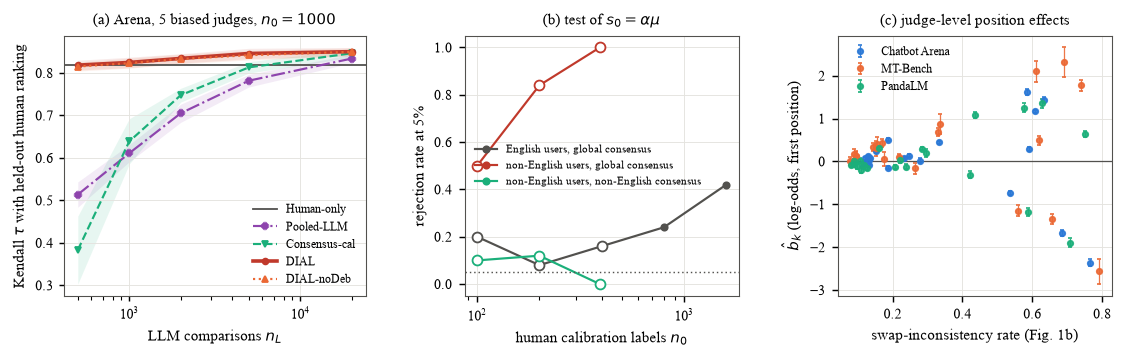

,kind,level,n,reject_rate,stat_mean,df,ho_exists,excess_restricted,excess_full,tau_mu,n_0
0,english_global,100.0,50,0.2,22.528,18.0,0.02,0.016,1.157,0.845,100
1,english_global,200.0,50,0.08,20.943,18.0,0.66,0.013,0.152,0.845,200
2,english_global,400.0,50,0.16,20.565,18.0,0.96,0.012,0.044,0.845,400
3,english_global,800.0,50,0.24,23.463,18.0,1.00,0.011,0.021,0.845,800
4,english_global,1600.0,50,0.42,28.073,18.0,1.00,0.011,0.014,0.845,1600
5,nonenglish_global,100.0,50,0.5,28.871,18.0,0.04,0.120,1.482,0.595,100
6,nonenglish_global,200.0,50,0.84,40.655,18.0,0.38,0.115,0.287,0.595,200
7,nonenglish_global,400.0,50,1.0,58.510,18.0,0.96,0.115,0.105,0.595,392
8,nonenglish_global,800.0,50,1.0,58.510,18.0,0.96,0.115,0.105,0.595,392
9,nonenglish_global,1600.0,50,1.0,58.510,18.0,0.96,0.115,0.105,0.595,392


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10.4, 2.6), gridspec_kw=dict(width_ratios=[1.1, 1.0, 1.0], wspace=0.35))
# (a) LLM budget on Kendall tau
ax = axes[0]
if "arena_33k" in agg:
    g = agg["arena_33k"][(agg["arena_33k"].sweep == "llm_budget") & (agg["arena_33k"].panel == "biased5") & (agg["arena_33k"].n_0_level == 1000)]
    for m in PRESENTED:
        gm = g[g.method == m].sort_values("level"); st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker")
        if m == "human_only": ax.axhline(gm.ref_kendall_mean.mean(), color=st["color"], lw=1.0, label=LABEL[m]); continue
        ax.plot(gm.level, gm.ref_kendall_mean, lw=lw, marker=mk, ms=3.2, label=LABEL[m], **st)
        ax.fill_between(gm.level, gm.ref_kendall_mean - 1.96 * gm.ref_kendall_se, gm.ref_kendall_mean + 1.96 * gm.ref_kendall_se, color=st["color"], alpha=0.10, lw=0)
    ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter()); ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)
ax.set_xlabel("LLM comparisons $n_L$"); ax.set_ylabel("Kendall $\\tau$ with held-out human ranking"); ax.set_title("(a) Arena, 5 biased judges, $n_0=1000$", fontsize=8.5)
ax.legend(frameon=False, fontsize=6.5, loc="lower right")
# (b) specification test
ax = axes[1]
if not spec.empty:
    scol = {"english_global": ("#52514e", "English users, global consensus"), "nonenglish_global": ("#c0392b", "non-English users, global consensus"), "nonenglish_subset": ("#1baf7a", "non-English users, non-English consensus")}
    for k, (c, lab) in scol.items():
        g = spec[spec.kind == k].sort_values("n_0").drop_duplicates("n_0")
        ax.plot(g.n_0, g.reject_rate, color=c, marker="o", ms=3.5, lw=1.2, label=lab)
        bad = g[g.ho_exists < 1]; ax.scatter(bad.n_0, bad.reject_rate, s=30, facecolors="white", edgecolors=c, zorder=3)
    ax.axhline(0.05, color=INK_SOFT, ls=(0, (1, 2)), lw=0.8); ax.set_xscale("log"); ax.set_ylim(-0.05, 1.05); ax.set_xlabel("human calibration labels $n_0$"); ax.set_ylabel("rejection rate at 5%")
    ax.set_title("(b) test of $s_0=\\alpha\\mu$", fontsize=8.5); ax.legend(frameon=False, fontsize=6.2, loc="center left"); ax.grid(True, color=GRID, lw=0.5)
# (c) judge-level position effects
ax = axes[2]; col3 = {"arena_33k": "#2a78d6", "mt_bench": "#eb6834", "pandalm": "#1baf7a"}
for d in DATASETS:
    cf = RESULTS / d / "clean_fit.json"; runs = sorted((REPO / "results" / "motivation").glob(f"{d}-*"))
    if not cf.exists() or not runs: continue
    f = json.load(open(cf)); mot = pd.read_csv(runs[-1] / "per_judge.csv").set_index("judge")
    x = np.array([mot.loc[j, "swap_inconsistency_rate"] if j in mot.index else np.nan for j in f["judges"]]); b = np.array(f["b"]); lo = np.array(f["b_lower"]); hi = np.array(f["b_upper"])
    ax.errorbar(x, b, yerr=[b - lo, hi - b], fmt="o", ms=3, lw=0.7, capsize=1.2, color=col3[d], label=DLAB[d], alpha=0.9)
ax.axhline(0, color=INK_SOFT, lw=0.7); ax.set_xlabel("swap-inconsistency rate (Fig. 1b)"); ax.set_ylabel("$\\hat b_k$ (log-odds, first position)"); ax.set_title("(c) judge-level position effects", fontsize=8.5)
ax.grid(True, color=GRID, lw=0.5); ax.legend(frameon=False, fontsize=6.5)
fig.savefig(FIGURES / "fig_real_main.pdf", bbox_inches="tight"); plt.show()
if not spec.empty: display(spec.round(3))

## Appendix figure: human-record efficiency

Top: human budget with the as-collected balanced LLM data (all 21 judges); the LLM-anchored estimators sit at the LLM floor from a few hundred labels while human-only needs the full pool. Human-only is off the chart at the smallest budgets, where its MLE does not exist.
Bottom: LLM rows subsampled to $n_L$ at fixed human budgets on Arena; with ten or fewer judgments per pair the joint estimators (DIAL-$\mu$, DIAL) beat both the staged consensus and human-only. Dotted: the weight minimizing the test log loss.

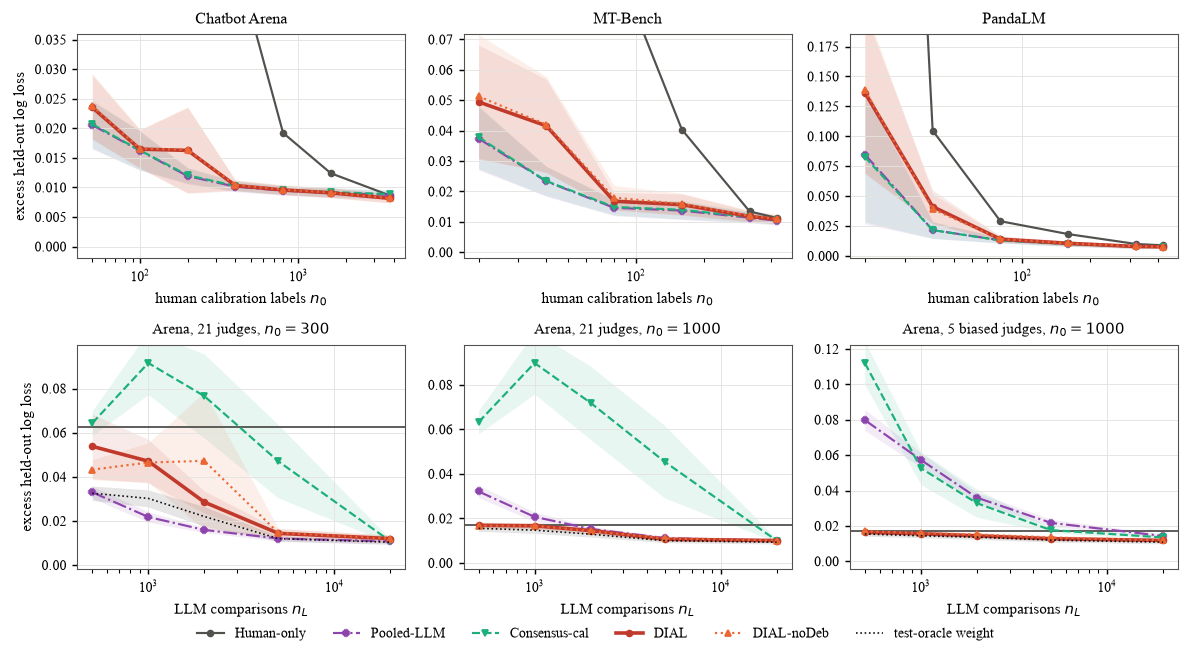

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(9.2, 4.9))
methods_C1 = list(PRESENTED)
for ax, d in zip(axes[0], DATASETS):
    if d in agg:
        curve(ax, agg[d], "budget", "all", "none", methods_C1, x="n_0", logx=True, hline_human=False)
        g = agg[d][(agg[d].sweep == "budget") & (agg[d].method != "human_only") & (agg[d].method.isin(methods_C1))]
        ax.set_ylim(min(g.excess_mean.min(), g.floor.mean() * 0) - 0.002, g.excess_mean.max() * 1.3 + 0.005)
    ax.set_title(DLAB[d]); ax.set_xlabel("human calibration labels $n_0$")
axes[0, 0].set_ylabel("excess held-out log loss")
methods_C2 = list(PRESENTED) + ["oracle_test"]
for ax, (panel, n0, ttl) in zip(axes[1], [("all", 300, "Arena, 21 judges, $n_0=300$"), ("all", 1000, "Arena, 21 judges, $n_0=1000$"), ("biased5", 1000, "Arena, 5 biased judges, $n_0=1000$")]):
    if "arena_33k" in agg:
        curve(ax, agg["arena_33k"], "llm_budget", panel, "none", methods_C2, n_0_level=n0, logx=True); clip_axis(ax, agg["arena_33k"], "llm_budget", panel, "none", methods_C2, n_0_level=n0)
    ax.set_title(ttl, fontsize=8.5); ax.set_xlabel("LLM comparisons $n_L$")
axes[1, 0].set_ylabel("excess held-out log loss")
h1, l1 = axes[0, 0].get_legend_handles_labels(); h2, l2 = axes[1, 0].get_legend_handles_labels()
seen = {}; [seen.setdefault(l, h) for h, l in list(zip(h1, l1)) + list(zip(h2, l2))]
fig.legend(list(seen.values()), list(seen.keys()), loc="lower center", ncol=8, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_efficiency.pdf", bbox_inches="tight"); plt.show()

## Appendix figure: budget planning from a pilot

From a pilot of $n_{\mathrm{pilot}}$ human labels, the specification-test statistic $T$ gives the point estimate $\widehat\Delta = \max\{0, (T - \mathrm{df})/(2n_{\mathrm{pilot}})\}$ and, by inverting the noncentral $\chi^2_{\mathrm{df}}$ distribution of $T$, a two-sided 90% interval $[\widehat\Delta_{\mathrm{lo}}, \widehat\Delta_{\mathrm{hi}}]$ for the anchor's misspecification $\Delta_W$.
Predicted excess (relative to the in-sample test-pool floor, whose optimism $(N-1)/(2n_{\mathrm{test}})$ is added back): anchored $\Delta + (r+1)/(2n)$ at the point estimate (line) and at the two interval ends (band); human-only $(N-1)/(2n)$; the crossover $n^\star=(N-r-2)/(2\Delta)$ is drawn at the point estimate (dashed) and as the interval implied by $[\widehat\Delta_{\mathrm{lo}}, \widehat\Delta_{\mathrm{hi}}]$ (grey span, open to the right when the lower end is zero).
All quantities are medians over the 50 pilots; the mean gives interval ends within 0.002 of the median ends, so the choice of aggregate no longer matters once the interval replaces the point estimate.
Observed curves are the 50-seed `budget` sweep (Consensus-cal and human-only).

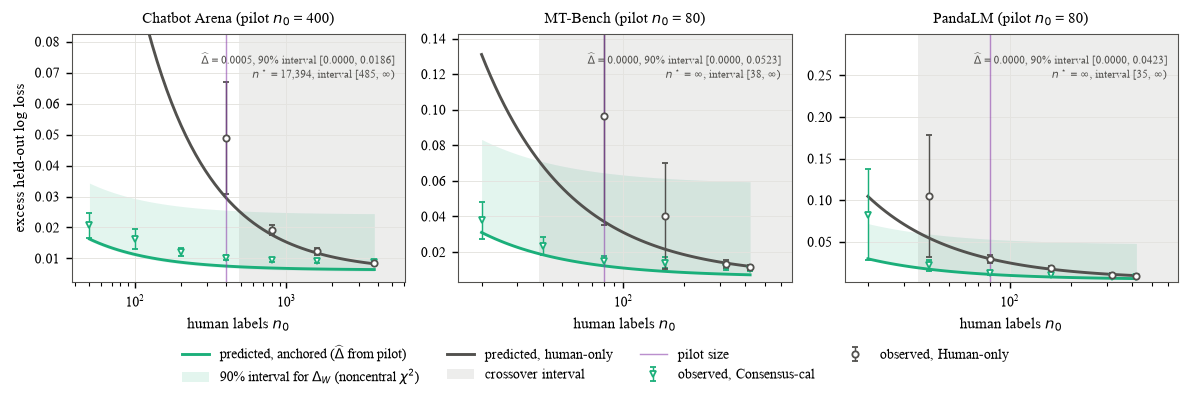

,dataset,n_pilot,delta_hat_median,delta_lo_median,delta_hi_median,delta_hat_mean,delta_lo_mean,delta_hi_mean,delta_all_train,n_star_point,n_star_interval_lo,n_star_interval_hi,n_star_observed,share_pilots_delta_zero,share_pilots_interval_lo_zero,coverage_of_fullpool
0,Chatbot Arena,400,0.0005,0.0,0.0186,0.0043,0.0005,0.0197,0.0013,17394.0757,484.8452,inf,3556.8511,0.46,0.88,0.88
1,MT-Bench,80,0.0000,0.0,0.0523,0.0065,0.0003,0.0542,0.0000,inf,38.2414,inf,NaN,0.54,0.96,0.96
2,PandaLM,80,0.0000,0.0,0.0423,0.0038,0.0001,0.0433,0.0000,inf,35.4775,inf,NaN,0.64,0.98,0.98


,dataset,n_pilot,delta_hat_median,delta_hat_q10,delta_hat_q90,n_star_median,labels_to_eps_anchored_median,labels_to_eps_human_only,eps
0,Chatbot Arena,100,0.0171,0.0,0.0470,410.1687,inf,950.0,0.01
1,Chatbot Arena,200,0.0058,0.0,0.0361,724.5055,120.4057,950.0,0.01
2,Chatbot Arena,400,0.0005,0.0,0.0140,1648.8709,52.7817,950.0,0.01
3,MT-Bench,40,0.0105,0.0,0.0551,64.0439,inf,250.0,0.01
4,MT-Bench,80,0.0000,0.0,0.0210,208.4971,50.0000,250.0,0.01
5,MT-Bench,160,0.0000,0.0,0.0183,186.6898,50.0000,250.0,0.01
6,PandaLM,40,0.0000,0.0,0.0622,45.4733,50.0000,200.0,0.01
7,PandaLM,80,0.0000,0.0,0.0148,212.0522,50.0000,200.0,0.01
8,PandaLM,160,0.0000,0.0,0.0089,272.8127,50.0000,200.0,0.01


In [7]:
from experiments.real_data.robustness_plot import planner_frame, predicted_curves, planner_with_intervals
PILOT = {"arena_33k": 400, "mt_bench": 80, "pandalm": 80}
fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.7))
summary_rows = []
for ax, d in zip(axes, DATASETS):
    if d not in rows: continue
    pl = planner_with_intervals(planner_frame(rows[d])); obs = agg[d][(agg[d].sweep == "budget")]
    if pl.empty or obs.empty: ax.set_title(DLAB[d]); continue
    grid = np.geomspace(obs.n_0_mean.min(), obs.n_0_mean.max(), 60)
    pil = pl[pl.level == PILOT[d]]
    # point estimate and 90% interval for Delta_W, each summarized by the median over pilots
    d_med, d_lo, d_hi = float(pil.delta_hat.median()), float(pil.delta_lo.median()), float(pil.delta_hi.median())
    med = pil.iloc[0].copy(); med["delta_hat"] = d_med
    N_, r_ = med["N"], med["r"]; xr = grid.max() * 1.6
    pa_med, ph_med = predicted_curves(med, grid)
    lo_row = med.copy(); lo_row["delta_hat"] = d_lo; hi_row = med.copy(); hi_row["delta_hat"] = d_hi
    pa_lo, _ = predicted_curves(lo_row, grid); pa_hi, _ = predicted_curves(hi_row, grid)
    ax.plot(grid, pa_med, color=STYLE["consensus_cal"]["color"], lw=1.6, label="predicted, anchored ($\\widehat\\Delta$ from pilot)")
    ax.fill_between(grid, pa_lo, pa_hi, color=STYLE["consensus_cal"]["color"], alpha=0.12, lw=0, label="90% interval for $\\Delta_W$ (noncentral $\\chi^2$)")
    ax.plot(grid, ph_med, color=STYLE["human_only"]["color"], lw=1.6, label="predicted, human-only")
    n_hi = (N_ - r_ - 2) / (2 * d_hi) if d_hi > 0 else np.inf          # earliest crossover compatible with the interval
    n_lo = (N_ - r_ - 2) / (2 * d_lo) if d_lo > 0 else np.inf          # latest (inf when Delta = 0 is not excluded)
    ax.axvspan(n_hi, min(n_lo, xr), color=INK_SOFT, alpha=0.10, lw=0, label="crossover interval")
    for m, mk in (("consensus_cal", "v"), ("human_only", "o")):
        g = obs[obs.method == m].sort_values("n_0_mean")
        ax.errorbar(g.n_0_mean, g.excess_mean, yerr=1.96 * g.excess_se, fmt=mk, ms=3.5, color=STYLE[m]["color"], lw=0.8, capsize=1.5, label=f"observed, {LABEL[m]}", mfc="white")
    # crossovers
    zero_share = float((pil.delta_hat == 0).mean())
    n_star_pred = (N_ - r_ - 2) / (2 * d_med) if d_med > 0 else np.inf          # crossover of the two drawn curves
    if np.isfinite(n_star_pred) and n_star_pred <= xr: ax.axvline(n_star_pred, color=INK_SOFT, ls="--", lw=0.9, label="predicted crossover $n^\\star$")
    txt = f"$\\widehat\\Delta$ = {d_med:.4f}, 90% interval [{d_lo:.4f}, {d_hi:.4f}]\n$n^\\star$ " + (f"= {n_star_pred:,.0f}" if np.isfinite(n_star_pred) else "= $\\infty$") + f", interval [{n_hi:,.0f}, " + (f"{n_lo:,.0f}]" if np.isfinite(n_lo) else "$\\infty$)")
    ax.text(0.97, 0.93, txt, ha="right", va="top", transform=ax.transAxes, fontsize=6.3, color=INK_SOFT)
    ax.set_xlim(grid.min() / 1.3, xr)
    gc = obs[obs.method == "consensus_cal"].set_index("n_0_mean").excess_mean.sort_index(); gh = obs[obs.method == "human_only"].set_index("n_0_mean").excess_mean.sort_index()
    diff = (gh - gc).dropna(); n_obs = np.nan
    for (x0, y0), (x1, y1) in zip(list(diff.items())[:-1], list(diff.items())[1:]):
        if y0 > 0 >= y1 or y0 >= 0 > y1: n_obs = np.exp(np.interp(0, [y1, y0], [np.log(x1), np.log(x0)])); break
    ax.axvline(PILOT[d], color="#8e44ad", lw=0.8, alpha=0.6, label="pilot size")
    lo = min(pa_med.min(), obs.excess_mean[obs.method == "consensus_cal"].min()); ax.set_ylim(lo - 0.004, 3.5 * obs.excess_mean[obs.method == "consensus_cal"].max() + 0.01)
    ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter()); ax.set_xlabel("human labels $n_0$"); ax.set_title(f"{DLAB[d]} (pilot $n_0$ = {PILOT[d]})", fontsize=8.5); ax.grid(True, color=GRID, lw=0.5)
    summary_rows.append(dict(dataset=DLAB[d], n_pilot=PILOT[d], delta_hat_median=d_med, delta_lo_median=d_lo, delta_hi_median=d_hi, delta_hat_mean=float(pil.delta_hat.mean()), delta_lo_mean=float(pil.delta_lo.mean()), delta_hi_mean=float(pil.delta_hi.mean()),
                             delta_all_train=float(pl.delta_all.median()), n_star_point=float(n_star_pred), n_star_interval_lo=float(n_hi), n_star_interval_hi=float(n_lo), n_star_observed=float(n_obs),
                             share_pilots_delta_zero=zero_share, share_pilots_interval_lo_zero=float((pil.delta_lo == 0).mean()), coverage_of_fullpool=float(((pil.delta_lo <= pil.delta_all) & (pil.delta_all <= pil.delta_hi)).mean())))
axes[0].set_ylabel("excess held-out log loss")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.14))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_planner.pdf", bbox_inches="tight"); plt.show()
planner_summary = pd.DataFrame(summary_rows); display(planner_summary.round(4))
# sensitivity to the pilot size and budgets to reach a target
tab = []
for d in rows:
    pl = planner_frame(rows[d])
    for n_p, g in pl.groupby("level"):
        eps = 0.01
        n_anchor = np.where(g.delta_hat < eps, (g.r + 1) / (2 * (eps - g.delta_hat)), np.inf)
        tab.append(dict(dataset=DLAB[d], n_pilot=int(n_p), delta_hat_median=g.delta_hat.median(), delta_hat_q10=g.delta_hat.quantile(0.1), delta_hat_q90=g.delta_hat.quantile(0.9),
                        n_star_median=np.nanmedian(g.n_star.replace(np.inf, np.nan)), labels_to_eps_anchored_median=float(np.nanmedian(n_anchor)), labels_to_eps_human_only=float(((g.N - 1) / (2 * eps)).iloc[0]), eps=eps))
pd.set_option("display.width", 250); display(pd.DataFrame(tab).round(4))

## Appendix figure: W-calibration and weight diagnostics

(a, b) DIAL against DIAL-W (calibration within $W=[\mu,V]$ at the same LLM rank) and the fixed-weight fits, on the LLM-budget sweep (five biased judges, $n_0=1{,}000$) and under injected anti-consensus judges in the scarce regime, Kendall $\tau$. (c) Share of seeds in which DIAL's GACV weight sits at each endpoint, and the median finite relative weight, against $n_L$.

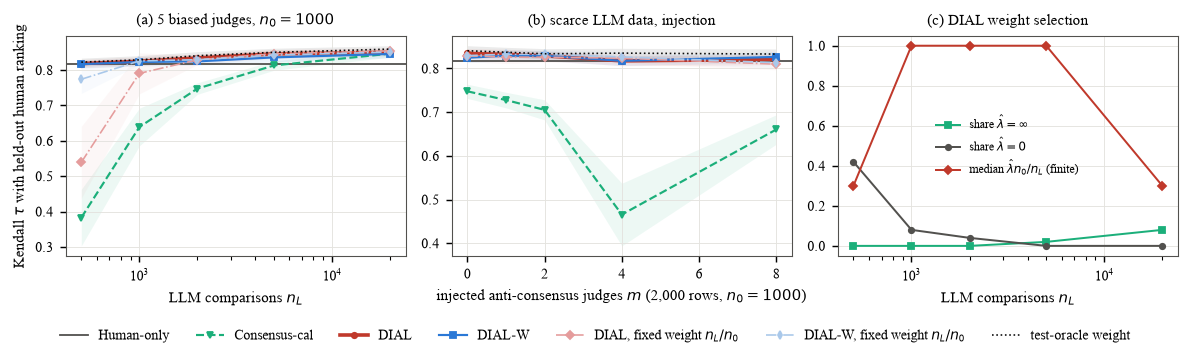

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.5))
diag = ["human_only", "consensus_cal", "dial_mu", "dial_w", "dial_mle_mu", "dial_mle_w", "oracle_test"]
def tau_lines(ax, g, methods, label=True):
    for m in methods:
        gm = g[g.method == m].sort_values("level"); st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker", None)
        if gm.empty: continue
        if m == "human_only": ax.axhline(gm.ref_kendall_mean.mean(), color=st["color"], lw=1.0, label=LABEL[m] if label else None); continue
        ax.plot(gm.level, gm.ref_kendall_mean, lw=lw, marker=mk, ms=3, label=LABEL[m] if label else None, **st)
        ax.fill_between(gm.level, gm.ref_kendall_mean - 1.96 * gm.ref_kendall_se, gm.ref_kendall_mean + 1.96 * gm.ref_kendall_se, color=st["color"], alpha=0.08, lw=0)
if "arena_33k" in agg:
    a = agg["arena_33k"]
    tau_lines(axes[0], a[(a.sweep == "llm_budget") & (a.panel == "biased5") & (a.n_0_level == 1000)], diag)
    axes[0].set_xscale("log"); axes[0].set_xlabel("LLM comparisons $n_L$"); axes[0].set_ylabel("Kendall $\\tau$ with held-out human ranking"); axes[0].set_title("(a) 5 biased judges, $n_0=1000$", fontsize=8.5)
    tau_lines(axes[1], a[(a.sweep == "noise_scarce") & (a.panel == "biased5") & (a.kind == "anti")], diag, label=False)
    axes[1].set_xlabel("injected anti-consensus judges $m$ (2,000 rows, $n_0=1000$)"); axes[1].set_title("(b) scarce LLM data, injection", fontsize=8.5)
    g = a[(a.sweep == "llm_budget") & (a.panel == "biased5") & (a.n_0_level == 1000) & (a.method == "dial_mu")].sort_values("level")
    axes[2].plot(g.level, g.lam_inf_frac, marker="s", ms=3, lw=1.1, color=STYLE["consensus_cal"]["color"], label="share $\\hat\\lambda=\\infty$")
    axes[2].plot(g.level, g.lam_zero_frac, marker="o", ms=3, lw=1.1, color=STYLE["human_only"]["color"], label="share $\\hat\\lambda=0$")
    axes[2].plot(g.level, g.lam_rel_med.fillna(0), marker="D", ms=3, lw=1.1, color=STYLE["dial_mu"]["color"], label="median $\\hat\\lambda n_0/n_L$ (finite)")
    axes[2].set_xscale("log"); axes[2].set_xlabel("LLM comparisons $n_L$"); axes[2].set_title("(c) DIAL weight selection", fontsize=8.5); axes[2].legend(frameon=False, fontsize=6.5)
for ax in axes: ax.grid(True, color=GRID, lw=0.5)
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=7, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_diagnostics.pdf", bbox_inches="tight"); plt.show()

## Tables behind the figures

In [9]:
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for d in agg:
    for (sw, pn, kd), g in agg[d].groupby(["sweep", "panel", "kind"]):
        piv = g.pivot_table(index=["level", "n_0_level"], columns="method", values="excess_mean").reindex(columns=list(PRESENTED) + ["dial_w", "staged_w", "dial_mle_mu", "dial_mle_w", "oracle_test", "dial_rsel"])
        print(f"=== {DLAB[d]} | {sw} | panel={pn} | kind={kd}  (excess held-out log loss, mean over {int(g.n.max())} seeds)"); print(piv.round(4).to_string()); print()

=== Chatbot Arena | budget | panel=all | kind=none  (excess held-out log loss, mean over 50 seeds)
method             human_only  pooled_cal  consensus_cal  dial_mu  dial_nodeb  dial_w  staged_w  dial_mle_mu  dial_mle_w  oracle_test  dial_rsel
level   n_0_level                                                                                                                               
-1.0    -1             0.0086      0.0087         0.0089   0.0081      0.0082  0.0087    0.0090       0.0088      0.0089       0.0075     0.0085
 50.0   -1             6.6515      0.0205         0.0207   0.0235      0.0238  0.0464    0.0443       0.0207      0.0472       0.0201     0.0679
 100.0  -1             1.0170      0.0162         0.0163   0.0165      0.0166  0.0283    0.0213       0.0163      0.0216       0.0156     0.0228
 200.0  -1             0.2220      0.0119         0.0121   0.0163      0.0164  0.0253    0.0146       0.0121      0.0148       0.0116     0.0163
 400.0  -1             0.0489  